# Supplemental Figure S11: Remake of Figure 3 with modified DMS probing conditions
data is stored in ../../../data

# setup and load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from dms_3d_features.plotting import (
    plot_pop_avg_from_row,
    publication_style_ax,
    plot_violins_w_percent,
    plot_motif_boxplot_stripplot,
    format_small_plot,
)

## extra functions

In [2]:
def plot_violinplot_with_percentages(df, y_column, color="tab:red", ax=None):
    # Calculate percentages
    percentages = (
        df.groupby(y_column)
        .apply(lambda x: (x["ln_r_data"] > -6.05).mean() * 100)
        .round(2)
    )

    # Sort y_column values by percentage
    sorted_y_values = percentages.sort_values(ascending=False).index

    if ax is None:
        fig, ax = plt.subplots(figsize=(2.0, 1.5), dpi=200)
    else:
        fig = ax.figure

    sns.violinplot(
        data=df,
        x="ln_r_data",
        y=y_column,
        density_norm="width",
        color=color,
        linewidth=0.5,
        order=sorted_y_values,
        ax=ax,
    )
    ax.axvline(-6.05, color="black", linestyle="--", lw=0.5)

    # Add percentage labels
    for i, y_value in enumerate(sorted_y_values):
        ax.text(-11.7, i, f"{percentages[y_value]:.2f}%", va="center", ha="right")

    ax.set_xlim(-15, -3)
    ax.set_xticks([-12, -10, -8, -6, -4, -2])
    ax.set_xlabel("ln(Mutation Fraction)", labelpad=2)
    y_label = ""
    if y_column == "p3_res":
        y_label = "3' Nucleotide"
    elif y_column == "p5_res":
        y_label = "5' Nucleotide"
    elif y_column == "r_stack":
        y_label = "Nucleotide Stack"
    ax.set_ylabel(y_label, labelpad=2)
    format_small_plot(ax)

    return fig, ax

### load data

In [6]:
REVISION_PATH = "../../data/revisions"
DATA_PATH = "../../data"

In [7]:
df_constructs = pd.read_json(f"{DATA_PATH}/raw-jsons/constructs/pdb_library_37C_2min.json")
df_constructs_nomod = pd.read_json(
    f"{DATA_PATH}/raw-jsons/constructs/pdb_library_nomod.json"
)
df = pd.read_json(f"{REVISION_PATH}/37c_2min/residues/pdb_library_37C_2min_residues.json")
df["ln_r_data"] = np.log(df["r_data"])
df["ln_r_data"].replace(-np.inf, -9.8, inplace=True)

df = df.query("r_data_outlier == False").copy()
df_wc = df.query("r_type == 'Flank-WC'").copy()

df_wc.sort_values("ln_r_data", inplace=True, ascending=False)

df_wc_high = df_wc.query("ln_r_data > -5.84").copy()
df_wc_high.sort_values("ln_r_data", inplace=True, ascending=False)

df_bp_details = pd.read_csv(f"{REVISION_PATH}/37c_2min/csvs/wc_details_37C_2min.csv")
df_bp_details = df_bp_details.query("flanking_pairs == 'YES'")
df_bp_details["ln_r_data"] = np.log(df_bp_details["r_data"])

/Users/sdeenalattha2/Desktop/2025_char_3d_struct_features/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/var/folders/jb/h5qjq4n15qg56r7dptdffxch5f0py6/T/ipykernel_32769/3822575257.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["ln_r_data"].replace(-np.inf, -9.8, inplace=True)
/Users/sdeenalattha2/Desktop/2025_char_3d_struct_features/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:399: Ru

# Plotting 

r_nuc
A    33.51
C    11.18
Name: ln_r_data, dtype: float64


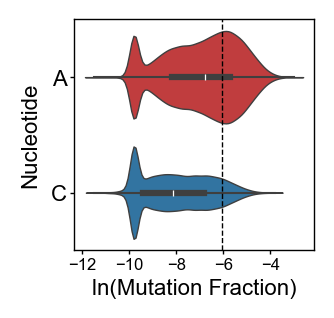

In [8]:
def figure_3a(df_wc, ax):
    """Create violin plot comparing A and C nucleotide mutation rates."""
    ax = sns.violinplot(
        data=df_wc,
        x="ln_r_data",
        y="r_nuc",
        hue="r_nuc",
        density_norm="width",
        palette=["tab:red", "tab:blue"],
        legend=False,
        linewidth=0.5,
        ax=ax,
    )
    ax.axvline(-6.05, color="black", linestyle="--", lw=0.5)
    ax.set_ylabel("Nucleotide")
    ax.set_xlabel("ln(Mutation Fraction)", labelpad=2)
    ax.set_xticks([-12, -10, -8, -6, -4])
    format_small_plot(ax)
    for label in ax.get_yticklabels():
        label.set_fontsize(8)
    return ax


fig, ax = plt.subplots(figsize=(2.0, 1.5), dpi=200)
figure_3a(df_wc, ax)
plt.savefig("pngs/figure_3a.png", dpi=600)
threshold = -6.05
percentages = (
    df_wc.groupby("r_nuc")["ln_r_data"]
         .apply(lambda s: (s > threshold).mean() * 100)
         .round(2)
)

print(percentages)

<Axes: xlabel='Nucleotide', ylabel='Mutation Fraction'>

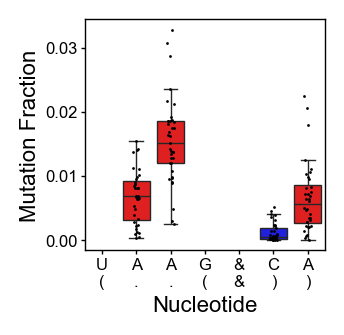

In [9]:
def figure_3b(df, ax):
    """Create boxplot with strip plot for UAAG&CA motif."""
    plot_motif_boxplot_stripplot(
        df.query("m_sequence == 'UAAG&CA'"), ax=ax, show_structure=True
    )
    format_small_plot(ax)
    return ax


fig, ax = plt.subplots(figsize=(2.0, 1.5), dpi=200)
figure_3b(df, ax)

/Users/sdeenalattha2/Desktop/2025_char_3d_struct_features/.venv/lib/python3.12/site-packages/dms_3d_features/plotting.py:420: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  percentages = df.groupby(y).apply(calculate_percentage)


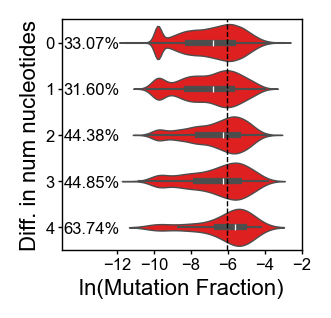

In [10]:
df_pos = df_wc.query("r_nuc == 'A'").copy()
df_pos["side_diff"] = [
    abs(int(x.split("x")[0]) - int(x.split("x")[1])) for x in df_pos["m_token"]
]
df_pos["side_diff"] = df_pos["side_diff"].astype(str)
df_pos.sort_values("side_diff", inplace=True, ascending=True)
fig, ax = plt.subplots(figsize=(2.0, 1.5), dpi=200)
plot_violins_w_percent(
    df_pos, "ln_r_data", "side_diff", cutoff=-6.05, text_offset=0.5, color="red", ax=ax
)
ax.set_xlim(-15, -3)
ax.set_xticks([-12, -10, -8, -6, -4, -2])
ax.set_xlabel("ln(Mutation Fraction)", labelpad=2)
ax.set_ylabel("Diff. in num nucleotides", labelpad=2)
format_small_plot(ax)

/var/folders/jb/h5qjq4n15qg56r7dptdffxch5f0py6/T/ipykernel_32769/3412503051.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x["ln_r_data"] > -6.05).mean() * 100)


(<Figure size 400x300 with 1 Axes>,
 <Axes: xlabel='ln(Mutation Fraction)', ylabel="5' Nucleotide">)

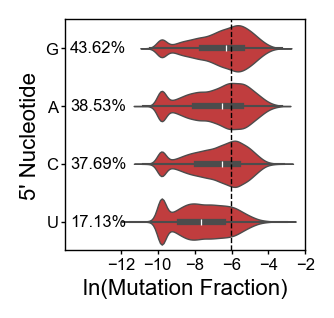

In [11]:
df_pos = df_wc.query("r_nuc == 'A'").copy()
fig, ax = plt.subplots(figsize=(2.0, 1.5), dpi=200)
plot_violinplot_with_percentages(df_pos, y_column="p5_res", color="tab:red", ax=ax)

/var/folders/jb/h5qjq4n15qg56r7dptdffxch5f0py6/T/ipykernel_32769/3412503051.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x["ln_r_data"] > -6.05).mean() * 100)


(<Figure size 400x300 with 1 Axes>,
 <Axes: xlabel='ln(Mutation Fraction)', ylabel="3' Nucleotide">)

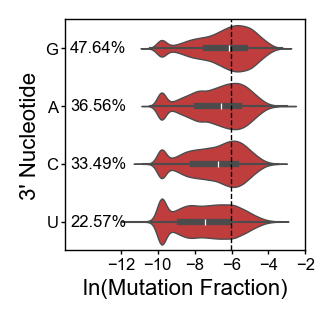

In [12]:
df_pos = df_wc.query("r_nuc == 'A'").copy()
fig, ax = plt.subplots(figsize=(2.0, 1.5), dpi=200)
plot_violinplot_with_percentages(df_pos, y_column="p3_res", color="tab:red", ax=ax)

/var/folders/jb/h5qjq4n15qg56r7dptdffxch5f0py6/T/ipykernel_32769/3412503051.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x["ln_r_data"] > -6.05).mean() * 100)


(<Figure size 400x740 with 1 Axes>,
 <Axes: xlabel='ln(Mutation Fraction)', ylabel='Nucleotide Stack'>)

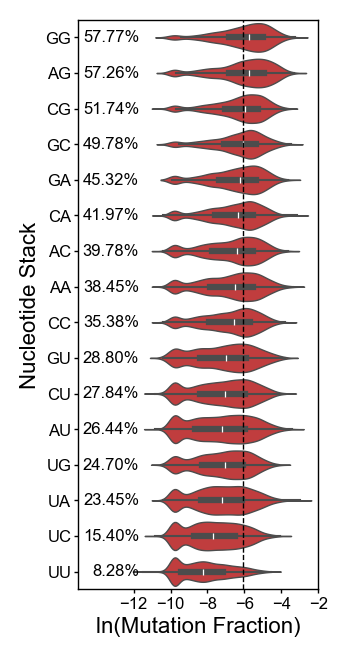

In [13]:
df_pos = df_wc.query("r_nuc == 'A'").copy()
fig, ax = plt.subplots(figsize=(2.0, 3.7), dpi=200)
plot_violinplot_with_percentages(df_pos, y_column="r_stack", color="tab:red", ax=ax)